# 🧬 Neural Networks & CNNs for DNA — a gentle, first introduction

**Week 18 · Computational Biology Bootcamp**

You already know **logistic regression** and **random forests**. This notebook builds
neural networks *on top of what you already know*, using a real genomics problem.

### What we are actually predicting (an honest framing)

The classic UCI dataset we use is a **splice-junction** dataset. Each example is a
short 60-base DNA window, and the task is to classify the window as one of:

| Class | Meaning |
|-------|---------|
| **EI** | an **E**xon→**I**ntron boundary (a *donor* splice site) |
| **IE** | an **I**ntron→**E**xon boundary (an *acceptor* splice site) |
| **N**  | **N**either — no splice junction here |

So the honest name for this task is **splice-junction / sequence-motif classification**,
not "mutation prediction." We'll keep that accurate throughout — and at the very end
we'll show how the *exact same recipe* transfers to real **mutation / variant-effect
prediction**, which is where the week's theme lands.

### The learning arc (the whole point of this notebook)

> **logistic regression = one neuron → stack neurons into a network (MLP) → give the
> network a "motif scanner" (CNN)**

We train every model on the *same* splice data and compare them honestly. Each jump is
small, and each new idea is tied back to something you already understand.

## 0 · Setup

We use **PyTorch** for the neural networks and **scikit-learn** for the baselines
(logistic regression, random forest) and evaluation metrics. Everything runs on **CPU**
in a couple of minutes.

We also fix random seeds so your results match ours (reproducibility).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- reproducibility: same seeds -> same numbers every run -------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")   # this dataset is tiny; CPU is plenty
print("PyTorch:", torch.__version__)
print("Running on:", device)

PyTorch: 2.9.1+cu128
Running on: cpu


## 1 · Biology first — what is a splice junction, and why does *local* sequence matter?

Before any math, let's ground the problem.

A gene in your DNA is not one continuous coding stretch. It alternates between:

- **exons** — the parts that are *kept* and end up coding for protein, and
- **introns** — the parts that are *spliced out* and thrown away.

```
  DNA:   ...==EXON==[----intron----]==EXON==...
                    ^              ^
                    |              |
              donor site      acceptor site
               (EI: exon→intron)   (IE: intron→exon)
```

For the cell's splicing machinery to cut in exactly the right place, there are short,
recurring **sequence patterns (motifs)** right at the boundary. The most famous:
introns very often **start with `GT`** (the donor/EI side) and **end with `AG`**
(the acceptor/IE side) — the classic *"GT–AG rule."*

**The key idea for this whole notebook:** the signal that tells EI from IE from N is
**local** — it lives in a few bases right around the middle of our 60-base window.
This is *exactly* the kind of structure that convolutional neural networks are built to
find, which is why CNNs are a natural fit for DNA. Hold onto that thought.

Let's load the data and look at it as biologists first — a few raw sequences and the
class balance.

In [2]:
# Each line: class, instance-name, 60-base sequence  (comma-delimited, padded with spaces)
col_names = ["label", "name", "sequence"]
df = pd.read_csv("splice.data", header=None, names=col_names,
                 skipinitialspace=True)
df["sequence"] = df["sequence"].str.strip()
df["name"] = df["name"].str.strip()

print("Total examples:", len(df))
print("Sequence length:", df["sequence"].str.len().unique(), "bases each")
df.head()

Total examples: 3190
Sequence length: [60] bases each


,label,name,sequence
0,EI,ATRINS-DONOR-521,CCAGCTGCATCACAGGAGGCCAGCGAGCAGGTCTGTTCCAAGGGCC...
1,EI,ATRINS-DONOR-905,AGACCCGCCGGGAGGCGGAGGACCTGCAGGGTGAGCCCCACCGCCC...
2,EI,BABAPOE-DONOR-30,GAGGTGAAGGACGTCCTTCCCCAGGAGCCGGTGAGAAGCGCAGTCG...
3,EI,BABAPOE-DONOR-867,GGGCTGCGTTGCTGGTCACATTCCTGGCAGGTATGGGGCGGGGCTT...
4,EI,BABAPOE-DONOR-2817,GCTCAGCCCCCAGGTCACCCAGGAACTGACGTGAGTGTCCCCATCC...


label
N     1655
IE     768
EI     767
Name: count, dtype: int64

Majority-class ('N') baseline accuracy = 0.519
Any model worth keeping must beat this ~52% by predicting N every time.


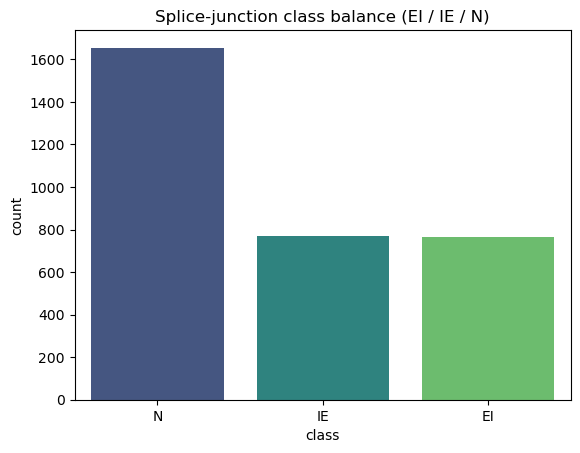

In [3]:
# Class balance -- notice this is IMBALANCED (N is the majority)
counts = df["label"].value_counts()
print(counts)

majority_baseline = counts.max() / counts.sum()
print(f"\nMajority-class ('N') baseline accuracy = {majority_baseline:.3f}")
print("Any model worth keeping must beat this ~52% by predicting N every time.")

sns.barplot(x=counts.index, y=counts.values, hue=counts.index, legend=False,
            palette="viridis")
plt.ylabel("count"); plt.xlabel("class")
plt.title("Splice-junction class balance (EI / IE / N)")
plt.show()

`★ Insight ─────────────────────────────────────`
- Because the data is **imbalanced** (N ≈ 52%), *accuracy alone can lie*: a model that
  always says "N" already scores ~52%. That's our **baseline to beat**, and it's why
  we'll always look at a **confusion matrix** and **per-class precision/recall**, not
  just one accuracy number.
- The biology tells us the discriminating signal is **local** (a few bases at the
  junction). Remember this when we get to CNNs.
`─────────────────────────────────────────────────`

## 1b · Turning DNA letters into numbers — one-hot encoding

Models do math on numbers, not on the letters `A/C/G/T`. The standard trick for DNA is
**one-hot encoding**: each base becomes a length-4 vector with a single `1`.

```
A -> [1, 0, 0, 0]
C -> [0, 1, 0, 0]
G -> [0, 0, 1, 0]
T -> [0, 0, 0, 1]
```

So a 60-base sequence becomes a **60 × 4** grid — think of it as a tiny image with
4 "channels," one per base. We deliberately *don't* map A→1, C→2, G→3, T→4, because that
would falsely tell the model "T is bigger than A" — the bases are categories, not
quantities.

**One wrinkle — ambiguity codes.** Real sequence data isn't always a clean ACGT. This
file contains a few IUPAC ambiguity codes (`N`, `D`, `R`, `S`) where the base wasn't
called cleanly. We handle any non-ACGT letter by spreading the probability **evenly
(0.25) across all four channels** — an honest "we don't know which base this is."

In [4]:
# Map each base to an index; anything else (N, D, R, S ...) -> "unknown"
BASE_TO_IDX = {"A": 0, "C": 1, "G": 2, "T": 3}
SEQ_LEN = 60

def one_hot_encode(seq):
    """60-base string -> (60, 4) one-hot array. Unknown bases -> uniform 0.25."""
    arr = np.zeros((SEQ_LEN, 4), dtype=np.float32)
    for i, base in enumerate(seq):
        idx = BASE_TO_IDX.get(base)
        if idx is None:            # ambiguity code: we don't know the base
            arr[i, :] = 0.25       # spread evenly across A/C/G/T
        else:
            arr[i, idx] = 1.0
    return arr

# quick check on one sequence
demo = one_hot_encode(df["sequence"].iloc[0])
print("Encoded shape (bases x channels):", demo.shape)
print("First 5 bases of sequence 0:", df["sequence"].iloc[0][:5])
print(demo[:5])

Encoded shape (bases x channels): (60, 4)
First 5 bases of sequence 0: CCAGC
[[0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]]


In [5]:
# Encode every sequence -> X_img has shape (n_examples, 60, 4)
X_img = np.stack([one_hot_encode(s) for s in df["sequence"]])

# Labels -> integers  (EI=0, IE=1, N=2)
CLASSES = ["EI", "IE", "N"]
LABEL_TO_INT = {c: i for i, c in enumerate(CLASSES)}
y = df["label"].map(LABEL_TO_INT).values

print("X_img shape:", X_img.shape, " (examples, bases, channels)")
print("y shape:", y.shape, " values:", np.unique(y))

X_img shape: (3190, 60, 4)  (examples, bases, channels)
y shape: (3190,)  values: [0 1 2]


### Train / test split — *stratified*, because the data is imbalanced

We hold out 25% of the data to test on. We use `stratify=y` so the EI/IE/N proportions
are the **same** in train and test — otherwise an unlucky split could put too few EIs in
the test set and make our metrics meaningless.

We keep two views of the same split:
- `X_flat` — the 60×4 grid **flattened to 240 numbers**, for logistic regression / random
  forest / the MLP (these models just want a flat feature vector).
- `X_img` — kept as a **60×4 grid**, for the CNN (which needs the spatial layout).

In [6]:
X_flat = X_img.reshape(len(X_img), -1)   # (n, 240)

# one split, reused everywhere (same indices) so comparisons are fair
idx_train, idx_test = train_test_split(
    np.arange(len(y)), test_size=0.25, random_state=SEED, stratify=y
)

X_flat_train, X_flat_test = X_flat[idx_train], X_flat[idx_test]
X_img_train,  X_img_test  = X_img[idx_train],  X_img[idx_test]
y_train,      y_test       = y[idx_train],      y[idx_test]

print("train:", X_flat_train.shape, " test:", X_flat_test.shape)
print("test class balance:", np.bincount(y_test))

train: (2392, 240)  test: (798, 240)
test class balance: [192 192 414]


## 2 · The bridge: **you already know a neuron**

Here's the single most important idea in this notebook.

**Logistic regression is literally one neuron.** When you fit a logistic regression, you
learn a weight for each input feature and a bias, then you do:

$$ z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b \qquad\text{then}\qquad \hat{p} = \sigma(z) $$

- multiply each input by a weight and add them up (**a weighted sum**),
- add a bias,
- squash the result through an **activation** (the sigmoid `σ`) to get a probability.

That "weighted sum → activation" unit **is a neuron.** A neural network is just *many*
of these neurons, wired in **layers**. So you're not learning something alien — you're
learning what happens when you stack a model you already understand.

Let's make that concrete: train the two models you already know — **logistic regression**
and **random forest** — as the **baselines every neural network must beat.**

In [7]:
# --- Baseline 1: Logistic Regression == a single-neuron model ----------------
logreg = LogisticRegression(max_iter=2000, random_state=SEED)
logreg.fit(X_flat_train, y_train)
logreg_pred = logreg.predict(X_flat_test)
logreg_acc = accuracy_score(y_test, logreg_pred)
print(f"Logistic Regression test accuracy: {logreg_acc:.3f}")

# --- Baseline 2: Random Forest (an ensemble you already know) ----------------
rf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
rf.fit(X_flat_train, y_train)
rf_pred = rf.predict(X_flat_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest       test accuracy: {rf_acc:.3f}")

print(f"\n(Majority-'N' baseline was {majority_baseline:.3f} — both should be well above it.)")

Logistic Regression test accuracy: 0.936


Random Forest       test accuracy: 0.957

(Majority-'N' baseline was 0.519 — both should be well above it.)


In [8]:
# Per-class report for logistic regression -- accuracy alone isn't enough
print("Logistic Regression -- per-class metrics:\n")
print(classification_report(y_test, logreg_pred, target_names=CLASSES))

Logistic Regression -- per-class metrics:

              precision    recall  f1-score   support

          EI       0.90      0.93      0.91       192
          IE       0.91      0.92      0.91       192
           N       0.97      0.95      0.96       414

    accuracy                           0.94       798
   macro avg       0.92      0.93      0.93       798
weighted avg       0.94      0.94      0.94       798



`★ Insight ─────────────────────────────────────`
- Logistic regression already does **surprisingly well** here — because one-hot DNA is a
  fairly *linear* problem when you hand it all 240 features. That's a healthy reminder:
  **don't reach for deep learning until a simple model has had its shot.**
- These two numbers are now our **bar**. A neural network that can't beat logistic
  regression isn't earning its complexity.
`─────────────────────────────────────────────────`

## 3 · One neuron → a network (a small MLP)

If one neuron is logistic regression, a **neural network** is just neurons stacked into
**layers**, where each layer feeds the next. The picture below is the mental model:

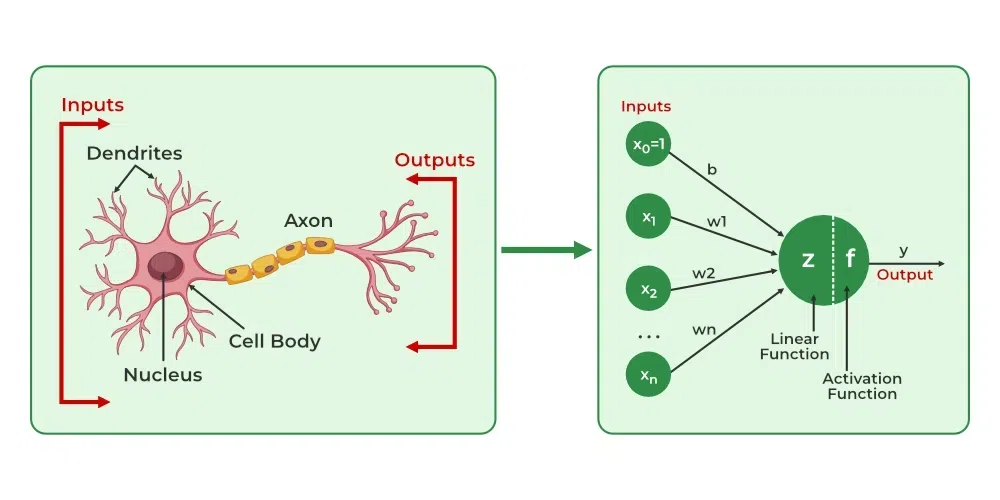

**How to read this diagram (input → hidden → output):**
- **Input layer (left):** one node per input feature. For us that's the 240 numbers of a
  flattened one-hot sequence.
- **Hidden layer(s) (middle):** each node is its own little neuron — a weighted sum of the
  previous layer, followed by an **activation** (we use **ReLU**, which simply keeps
  positive values and zeroes out negatives). Stacking these lets the network combine
  features into **new, learned features** — this is the power a single logistic
  regression doesn't have.
- **Output layer (right):** one node per class (EI / IE / N). A **softmax** turns those
  three numbers into probabilities that sum to 1, and we predict the largest.

### The vocabulary, defined *as we use it*

Training a network is a loop. Each pass over the data introduces one term:

- **forward pass** — push a batch of sequences through the layers to get predictions.
- **loss** — a number measuring how wrong those predictions are. For classification we
  use **cross-entropy loss** (low when the true class gets high probability).
- **backpropagation** — automatically compute how each weight should nudge to reduce the
  loss (PyTorch does this for us with `loss.backward()`).
- **optimizer** — the rule that applies those nudges. We use **Adam**, a solid default.
- **epoch** — one full pass over all the training data. We repeat for several epochs so
  the weights gradually improve.

Watch for these five words in the training loop below — that loop *is* the definition.

In [9]:
# Tensors for PyTorch. The MLP takes the FLAT 240-vector (like logreg/RF did).
Xtr = torch.tensor(X_flat_train, dtype=torch.float32)
Xte = torch.tensor(X_flat_test,  dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.long)
yte = torch.tensor(y_test,  dtype=torch.long)

class MLP(nn.Module):
    """A tiny network: 240 inputs -> 32 hidden neurons (ReLU) -> 3 class scores."""
    def __init__(self, n_in=240, n_hidden=32, n_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, n_hidden),   # a whole LAYER of neurons (weighted sums)
            nn.ReLU(),                   # activation: keep positives, zero negatives
            nn.Linear(n_hidden, n_classes)  # output layer: one score per class
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(SEED)
mlp = MLP().to(device)
print(mlp)
print("Trainable parameters:", sum(p.numel() for p in mlp.parameters()))

MLP(
  (net): Sequential(
    (0): Linear(in_features=240, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=3, bias=True)
  )
)
Trainable parameters: 7811


In [10]:
def train_model(model, X, y, Xval, yval, epochs=60, lr=1e-3, batch=64):
    """Generic training loop. Returns per-epoch train & validation accuracy."""
    loss_fn = nn.CrossEntropyLoss()               # the LOSS
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # the OPTIMIZER
    n = len(X)
    hist = {"train_acc": [], "val_acc": []}

    for epoch in range(epochs):                   # each epoch = one pass over the data
        model.train()
        perm = torch.randperm(n)                  # shuffle each epoch
        for i in range(0, n, batch):
            b = perm[i:i + batch]
            optimizer.zero_grad()
            logits = model(X[b])                  # forward pass
            loss = loss_fn(logits, y[b])          # how wrong are we?
            loss.backward()                       # backpropagation: compute gradients
            optimizer.step()                      # optimizer nudges the weights

        # --- evaluate this epoch (no gradient needed) ---
        model.eval()
        with torch.no_grad():
            tr_acc = (model(X).argmax(1) == y).float().mean().item()
            va_acc = (model(Xval).argmax(1) == yval).float().mean().item()
        hist["train_acc"].append(tr_acc)
        hist["val_acc"].append(va_acc)
    return hist

torch.manual_seed(SEED)
mlp_hist = train_model(mlp, Xtr, ytr, Xte, yte, epochs=60)
mlp_acc = mlp_hist["val_acc"][-1]
print(f"MLP final test accuracy: {mlp_acc:.3f}")
print(f"(logreg {logreg_acc:.3f} | rf {rf_acc:.3f})")

MLP final test accuracy: 0.922
(logreg 0.936 | rf 0.957)


`★ Insight ─────────────────────────────────────`
- Notice the MLP treats the sequence as **240 unordered numbers** — it has *no idea* that
  base 30 sits next to base 31. It can still learn, but it must rediscover any local
  structure from scratch. This is precisely the weakness the CNN will fix next.
- We reused **one** `train_model` loop for every network — the loop *is* the algorithm.
  Read it once and the words *epoch / loss / backprop / optimizer* stop being jargon.
`─────────────────────────────────────────────────`

## 4 · Why a CNN for DNA — a filter is a *learned motif detector*

Recall the biology: the signal is a **local motif** (like `GT` at a donor site) that can
sit anywhere around the junction. We want a model that can learn *"does this short
pattern appear here?"* and scan for it **all along the sequence.** That is exactly what a
**convolution** does.

- **filter / kernel** — a small weight pattern, say 6 bases wide across all 4 channels.
  Think of it as a **learnable consensus motif** (e.g. it might learn to light up on
  `...GT...`).
- **sliding / convolution** — we slide that filter along the 60 positions; at each spot we
  score how well the local sequence matches the filter.
- **feature map** — the resulting track of scores: *"how strongly did this motif appear at
  each position?"*
- **many filters** — a conv layer learns *many* filters at once, so it can detect several
  motifs (donor-like, acceptor-like, ...) in parallel.
- **pooling** — we then take the **max** over a window, which answers *"did this motif
  appear anywhere nearby?"* and makes the detection robust to the motif shifting a base or
  two.

Because a filter reuses the *same* weights at every position (**weight sharing**), a CNN
learns a motif **once** and finds it everywhere — far more efficient than the MLP relearning
it position by position.

In [11]:
# PyTorch Conv1d wants shape (batch, channels, length) = (n, 4, 60).
# Our X_img is (n, 60, 4), so we transpose the last two axes.
Xtr_img = torch.tensor(X_img_train, dtype=torch.float32).transpose(1, 2)
Xte_img = torch.tensor(X_img_test,  dtype=torch.float32).transpose(1, 2)
print("CNN input shape (batch, channels=4, length=60):", Xtr_img.shape)

class DNA_CNN(nn.Module):
    """1D CNN: scan for motifs -> pool -> classify EI/IE/N."""
    def __init__(self, n_classes=3):
        super().__init__()
        self.conv = nn.Conv1d(in_channels=4, out_channels=16,
                              kernel_size=6, padding=2)  # 16 motif detectors, 6bp wide
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)          # "did the motif appear nearby?"
        self.flatten = nn.Flatten()
        # length after conv/pool is computed once, lazily, below
        self.head = None
        self.n_classes = n_classes

    def forward(self, x):
        x = self.pool(self.relu(self.conv(x)))
        x = self.flatten(x)
        if self.head is None:                            # build classifier on first pass
            self.head = nn.Linear(x.shape[1], self.n_classes)
        return self.head(x)

torch.manual_seed(SEED)
cnn = DNA_CNN().to(device)
_ = cnn(Xtr_img[:2])           # one dummy pass to build the head
print(cnn)
print("Trainable parameters:", sum(p.numel() for p in cnn.parameters()))

CNN input shape (batch, channels=4, length=60): torch.Size([2392, 4, 60])
DNA_CNN(
  (conv): Conv1d(4, 16, kernel_size=(6,), stride=(1,), padding=(2,))
  (relu): ReLU()
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (head): Linear(in_features=464, out_features=3, bias=True)
)
Trainable parameters: 1795


In [12]:
torch.manual_seed(SEED)
cnn_hist = train_model(cnn, Xtr_img, ytr, Xte_img, yte, epochs=60)
cnn_acc = cnn_hist["val_acc"][-1]
print(f"CNN final test accuracy: {cnn_acc:.3f}")

CNN final test accuracy: 0.950


In [13]:
# The one honest results table
results = pd.DataFrame({
    "model": ["Majority-N baseline", "Logistic Regression (1 neuron)",
              "Random Forest", "MLP (neural net)", "1D CNN (motif scanner)"],
    "test_accuracy": [majority_baseline, logreg_acc, rf_acc, mlp_acc, cnn_acc],
}).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
results["test_accuracy"] = results["test_accuracy"].round(3)
results

,model,test_accuracy
0,Random Forest,0.957
1,1D CNN (motif scanner),0.950
2,Logistic Regression (1 neuron),0.936
3,MLP (neural net),0.922
4,Majority-N baseline,0.519


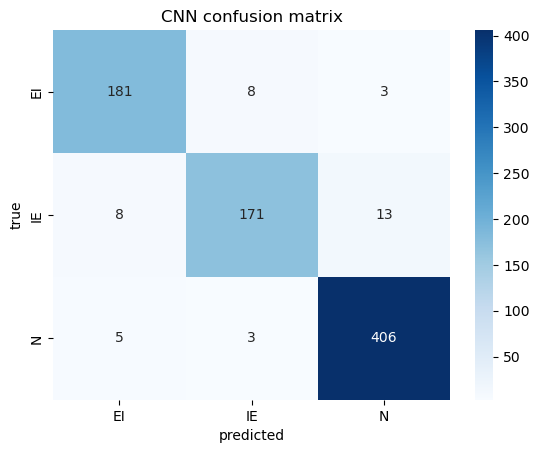

              precision    recall  f1-score   support

          EI       0.93      0.94      0.94       192
          IE       0.94      0.89      0.91       192
           N       0.96      0.98      0.97       414

    accuracy                           0.95       798
   macro avg       0.94      0.94      0.94       798
weighted avg       0.95      0.95      0.95       798



In [14]:
# Confusion matrix + per-class metrics for the CNN (accuracy alone isn't the story)
cnn.eval()
with torch.no_grad():
    cnn_pred = cnn(Xte_img).argmax(1).numpy()

cm = confusion_matrix(y_test, cnn_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("CNN confusion matrix")
plt.show()

print(classification_report(y_test, cnn_pred, target_names=CLASSES))

`★ Insight ─────────────────────────────────────`
- On this small, fairly linear dataset the CNN, MLP, logistic regression and random forest
  often land **close together** — and that's an honest, useful lesson: **deep learning is
  not automatically better.** Its advantage grows with longer sequences, more data, and
  subtler motifs, where hand-made features and linear models run out of room.
- The CNN's real win is *conceptual*: it learned **position-independent motif detectors**
  from raw sequence, with no feature engineering — the same machinery that scales up to
  genome-wide models.
`─────────────────────────────────────────────────`

## 5 · Overfitting & interpretability

**Overfitting** is when a model *memorizes* the training data instead of learning the
general rule — it aces the training set but stumbles on new data. You can literally *see*
it: the **training** accuracy keeps climbing while the **validation** accuracy stalls or
drops. The gap between the two curves is the overfitting.

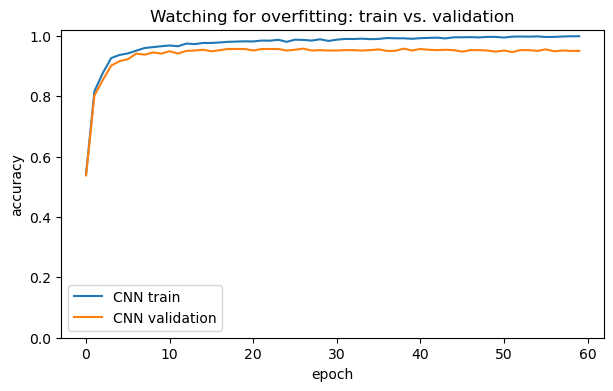

Final train-vs-validation gap: 0.048  (bigger gap = more overfitting)


In [15]:
plt.figure(figsize=(7, 4))
plt.plot(cnn_hist["train_acc"], label="CNN train")
plt.plot(cnn_hist["val_acc"],   label="CNN validation")
plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.title("Watching for overfitting: train vs. validation")
plt.legend(); plt.ylim(0, 1.02)
plt.show()

gap = cnn_hist["train_acc"][-1] - cnn_hist["val_acc"][-1]
print(f"Final train-vs-validation gap: {gap:.3f}  (bigger gap = more overfitting)")

**How we fight overfitting (intuition, not formulas):**

- **Dropout** — during training, randomly switch off a fraction of neurons each step. The
  network can't lean on any single neuron, so it learns sturdier, redundant features. (In
  PyTorch: add `nn.Dropout(0.3)` between layers.)
- **Early stopping** — just stop training at the epoch where *validation* accuracy peaks,
  before the gap widens. The curve above tells you where that is.
- **More data / weight regularization** — more examples, or gently penalizing large
  weights, both push the model toward simpler, more general rules.

**A word on interpretability.** A logistic regression is easy to read: each weight says how
much a feature pushes toward a class. A neural network trades some of that transparency for
power. But it isn't a total black box — in a DNA CNN you can pull out a learned **filter**
and ask *"what motif makes this filter fire hardest?"* Often it recovers a recognizable
biological signal (e.g. a `GT`-rich donor pattern). That bridge — **filter ↔ motif** — is
an active, useful area of genomics research.

## 6 · Bridging to mutations & beyond

We framed this honestly as **splice-junction classification** — so where do **mutations**
come in? The beautiful part: **the recipe doesn't change.**

> **encode DNA → convolve to detect motifs → classify**

This same pipeline is how modern **variant-effect / mutation-prediction** models work:

1. Take a stretch of DNA around a position — **the reference sequence.**
2. Make a second copy with the **mutation** applied (e.g. a single-base change).
3. Run **both** through a CNN like the one you just built.
4. The prediction **changes** between reference and mutant → the model is telling you the
   mutation likely **disrupts a functional signal** (for instance, breaking a splice-donor
   `GT` motif and causing an exon to be skipped).

That is exactly how tools reason about whether a variant is benign or damaging — a mutation
that destroys the motif your CNN learned is a mutation worth flagging. So the "toy" splice
classifier you built is a genuine, scaled-down version of a real clinical-genomics idea.

**Where this goes next:**
- **Deeper/residual CNNs** over much longer windows (thousands of bases).
- **RNNs / LSTMs** for longer-range dependencies along a sequence.
- **Transformers** (the architecture behind DNABERT, Enformer, the Nucleotide Transformer),
  which learn even longer-range genomic context.

Every one of them still starts where you did today: **turn sequence into numbers, let the
network learn the patterns.**

### 🎓 Recap — the arc you just walked

| Step | Model | Big idea you took away |
|------|-------|------------------------|
| 1 | Logistic regression | **one neuron** = weighted sum → activation |
| 2 | Random forest | strong classical baseline to respect |
| 3 | MLP | a network is **neurons stacked in layers** |
| 4 | 1D CNN | a **filter is a learned motif detector** that scans the sequence |
| 5 | — | **overfitting** (train vs. val gap) and how to curb it |
| 6 | — | the same recipe powers **mutation / variant-effect** prediction |

You didn't leave what you knew behind — you **grew it** into neural networks. That's the
whole point. 🧬

> **Optional — make it yours (5 minutes).** Try one small change and re-run the CNN cell:
> add `nn.Dropout(0.3)` after the ReLU, or change `kernel_size` from 6 to 3 or 11 (a wider
> filter = a longer motif). Watch the train-vs-validation curve and the results table move.
> Predicting *why* it moves — before you run it — is where the real learning happens.